# 专题：从并行计算到 CUDA Kernel

目标不是直接堆 CUDA 语法，而是先把一个更关键的问题讲透：

> **为什么要写 kernel，kernel 到底在解决什么问题，它和 DDP 又不是一回事。**

这份材料按下面的顺序展开：

1. 先把 `DDP` 和 `kernel` 区分开。
2. 用最简单的 `SAXPY` 说明什么叫“一个线程做一个输出元素”。
3. 用图像 blur / convolution 说明 stencil kernel。
4. 用矩阵乘法说明 block、tile、shared memory 为什么重要。
5. 用 reduction 说明另一类常见但更容易写错的 kernel 模式。
6. 最后再回到 PyTorch：卷积、matmul、attention 背后为什么都离不开 kernel。

## 本节课学习目标

1. 理解 `DDP` 和 `kernel` 的职责边界。
2. 建立 `grid / block / thread` 的并行直觉。
3. 理解三类经典 kernel：`pointwise`、`stencil`、`reduction`。
4. 理解为什么矩阵乘法常常要做 `tiling`。
5. 能把 kernel 思维和 PyTorch 里的实际算子联系起来。

## 先说清楚：什么是算子

在这类系统课里，**算子** 可以先粗略理解成：

> **对输入数据做一次明确计算的功能单元。**

例如下面这些都可以叫算子：

- `add`
- `matmul`
- `conv`
- `relu`
- `softmax`
- `layernorm`

可以把层次关系先记成：

- **模型**：很多层和很多步骤拼起来的整体
- **层**：往往由一个或多个算子组成
- **算子**：更底层、更具体的一次计算

所以后面讲 kernel 时，最重要的一句对应关系就是：

> **算子说的是“要做什么计算”，kernel 说的是“这个计算在设备上怎么执行”。**

## 先把 DDP 和 kernel 分开

<img src="images/lesson_kernel_intro/ddp_vs_kernel.png" width="980">

这里先说一句最容易混淆的话：

- **DDP** 关心的是：多张卡怎么一起训练一个模型。
- **kernel** 关心的是：单个算子怎么在一张卡上并行执行。

两者当然有关联，因为 DDP 的前向、反向、all-reduce 最后也都要落到具体 kernel 上。
但如果要讲“写 kernel”，核心不是梯度同步，而是：

> **如何把一个数学操作拆成很多小任务，让大量线程一起做。**

## 这一讲的主线

<img src="images/lesson_kernel_intro/kernel_roadmap.png" width="980">

一开始不要把注意力放在 CUDA API 上，先放在“计算模式”上。  
如果计算模式不清楚，语法学再多也会很散。

In [1]:
# ------------------------------
# 这段代码做什么：
# 1. 导入本节课会用到的库
# 2. 设置随机种子、作图风格和简单的计时工具
# ------------------------------
import math
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def benchmark(fn, *args, repeats=3, **kwargs):
    best = float("inf")
    out = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        dt = time.perf_counter() - t0
        best = min(best, dt)
    return out, best


print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

torch version: 2.10.0
CUDA available: False


# Part 1. Kernel 到底是什么

先用一句最朴素的话定义：

> **kernel 就是一段很小的程序，它会被很多线程同时执行。**

如果把 CPU 上的普通 `for` 循环想成：

- 一个工人
- 按顺序做完所有任务

那 kernel 更像是：

- 把大任务切成很多小片
- 交给很多工人同时做

最常见的第一种 kernel 是 **pointwise kernel**：

- 输入里有多少个元素
- 就开多少个逻辑线程
- 每个线程只负责一个输出位置

## 第一个例子：SAXPY

`SAXPY` 是并行计算里一个经典入门例子：

它的全称是：

> **Single-Precision A·X Plus Y**

可以直接拆开记：

- `S`：`Single-precision`，单精度浮点数
- `A`：一个标量 `a`
- `X`：向量 `x`
- `P`：`Plus`
- `Y`：向量 `y`

所以 `SAXPY` 本质上就是：

$$
y_i = a x_i + y_i
$$

它很适合解释 pointwise kernel，因为每个输出元素都互不依赖。  
这时候最自然的并行方式就是：

> **一个线程负责一个下标 `i`。**

### 先提醒一个很重要的工程习惯

在比较性能之前，应该先确认两种实现算的是不是同一个结果。  
所以后面代码里这句：

```python
print("max abs diff =", np.max(np.abs(out_python - out_numpy)))
```

不是为了“好看”，而是在做一个最基本的正确性检查：

- `out_python - out_numpy`：逐元素比较两种实现的结果差
- `np.abs(...)`：把误差都变成绝对值
- `np.max(...)`：取出最大的那个误差

也就是在问：

> **这两种写法虽然实现不同，但结果最多相差多少？**

这一步可以先记成一句简单原则：

> **先验证“算得对不对”，再比较“算得快不快”。**

In [2]:
# ------------------------------
# 这段代码做什么：
# 1. 先用纯 Python 循环实现 SAXPY
# 2. 再用 NumPy 向量化实现同样的数学操作
# 3. 对比“顺序做”和“成批做”的差别
# ------------------------------
def saxpy_python(a, x, y):
    out = np.empty_like(y)
    for i in range(len(x)):
        out[i] = a * x[i] + y[i]
    return out


def saxpy_numpy(a, x, y):
    return a * x + y


n = 200_000
a = 2.5
x = np.random.randn(n).astype(np.float32)
y = np.random.randn(n).astype(np.float32)

out_python, t_python = benchmark(saxpy_python, a, x, y, repeats=1)
out_numpy, t_numpy = benchmark(saxpy_numpy, a, x, y, repeats=5)

print("max abs diff =", np.max(np.abs(out_python - out_numpy)))
print(f"python loop time: {t_python:.4f}s")
print(f"numpy vectorized time: {t_numpy:.6f}s")

max abs diff = 0.0
python loop time: 0.0242s
numpy vectorized time: 0.000027s


### 这一步真正要说明什么

这里还不是 CUDA，但已经在为 kernel 建立直觉：

- **Python loop**：脑子里像“一个人按顺序做完所有元素”
- **NumPy vectorized**：脑子里像“把一批元素一起交给底层高效实现”

真正的 GPU kernel 则更进一步：

- 不是“把整批数据交出去就完了”
- 而是显式地思考：**一个线程负责哪个输出元素**

## grid / block / thread 的第一眼直觉

<img src="images/lesson_kernel_intro/grid_block_thread.png" width="940">

最常见的 1D kernel 下标写法就是：

```cpp
int idx = blockIdx.x * blockDim.x + threadIdx.x;
```

它的意思一点也不神秘，本质就是：

- `blockIdx.x`：现在是第几个 block
- `blockDim.x`：每个 block 里有多少个线程
- `threadIdx.x`：当前线程在本 block 里的编号

三者合起来，就得到“这个线程负责哪个全局位置”。

### 先用一个具体例子把这件事想清楚

假设这次要处理：

- `n = 20` 个元素，也就是全局下标 `0 ~ 19`
- `block_size = 6`，也就是每个 block 放 6 个线程

那就需要：

$$
\text{num_blocks} = \lceil 20 / 6 \rceil = 4
$$

所以这次会启动 4 个 block。  
每个 block 里的线程分工大致是：

- `block 0` 负责全局位置 `0 ~ 5`
- `block 1` 负责全局位置 `6 ~ 11`
- `block 2` 负责全局位置 `12 ~ 17`
- `block 3` 理论上会负责 `18 ~ 23`

但真正有效的数据只有 `0 ~ 19`，所以最后一个 block 里：

- `18`、`19` 是有效位置
- `20`、`21`、`22`、`23` 已经越界，没有真实任务

这就是为什么后面代码里会有：

```python
active = global_idx < n
```

它要表达的其实很朴素：

> **这个线程虽然被启动了，但它到底有没有真活干？**

所以下面这格代码，本质上是在打印一张“线程分工表”。

In [3]:
# ------------------------------
# 这段代码做什么：
# 1. 用 CPU 模拟一次 1D kernel launch
# 2. 直接打印每个线程会负责哪个全局下标
# ------------------------------
def simulate_1d_launch(n, block_size):
    num_blocks = math.ceil(n / block_size)
    mapping = []
    for block_idx in range(num_blocks):
        for thread_idx in range(block_size):
            global_idx = block_idx * block_size + thread_idx
            active = global_idx < n
            mapping.append((block_idx, thread_idx, global_idx, active))
    return mapping


mapping = simulate_1d_launch(n=20, block_size=6)
print("blockIdx  threadIdx  global_idx  active")
for row in mapping:
    print(f"{row[0]:>7}  {row[1]:>9}  {row[2]:>10}  {str(row[3]):>6}")

blockIdx  threadIdx  global_idx  active
      0          0           0    True
      0          1           1    True
      0          2           2    True
      0          3           3    True
      0          4           4    True
      0          5           5    True
      1          0           6    True
      1          1           7    True
      1          2           8    True
      1          3           9    True
      1          4          10    True
      1          5          11    True
      2          0          12    True
      2          1          13    True
      2          2          14    True
      2          3          15    True
      2          4          16    True
      2          5          17    True
      3          0          18    True
      3          1          19    True
      3          2          20   False
      3          3          21   False
      3          4          22   False
      3          5          23   False


### 这格代码要怎么讲

关键不是让人背 launch 公式，而是看懂两个事实：

1. **线程数通常会比真实元素数稍微多一点**  
   因为 block 大小一般固定，所以最后一个 block 往往会“多开几个线程”。

2. **所以边界判断几乎总是要写**

也就是 CUDA 代码里常见的：

```cpp
if (idx < n) {
    y[idx] = a * x[idx] + y[idx];
}
```

这不是语法细节，而是 kernel 的基本安全边界。

## 如果把 SAXPY 真写成 CUDA kernel，大概长这样

```cpp
__global__ void saxpy_kernel(float a, const float* x, float* y, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        y[idx] = a * x[idx] + y[idx];
    }
}
```

通俗地读这段代码：

- `__global__`：这是一段要交给 GPU 跑的 kernel
- 每个线程先算出自己负责的 `idx`
- 然后只处理那一个元素

所以一个 kernel 的核心问题通常只有两个：

1. **每个线程负责哪个输出**
2. **边界怎么保护**

# Part 2. 视觉里最常见的 kernel：stencil / convolution

pointwise kernel 很容易懂，因为一个输出只看一个输入。  
但视觉里大量操作都不是这样，比如：

- blur
- convolution
- Sobel edge
- Laplacian

它们的共同点是：

> **一个输出像素，要看输入图像的一小块邻域。**

### `stencil` 模式到底是什么意思

可以先很通俗地理解成：

> **算一个位置的输出时，要去看它周围一小圈邻居。**

它和前面的 `pointwise` 最大区别是：

- **pointwise**：一个输出只看一个输入  
  例如 `y[i] = x[i] + 1`

- **stencil**：一个输出要看一片局部邻域  
  例如 `y[i, j]` 要看 `x[i-1:i+2, j-1:j+2]`

在图像里，最常见的 stencil 例子就是：

- blur
- convolution
- Sobel 边缘
- Laplacian

所以可以把 `stencil` 直接记成一句话：

> **stencil = 邻域计算模式。**

为什么叫这个名字？  
因为它很像拿一个小模板贴在输入上：

- 模板盖住一小块区域
- 按模板规则做一次计算
- 然后滑到下一个位置继续做

## blur kernel 的心智图

<img src="images/lesson_kernel_intro/blur_stencil.png" width="900">

这类 kernel 常被叫做 `stencil`。  
在视觉里，它就是最直观的卷积思路：

- 给定一个输出位置
- 去输入图像里找对应邻域
- 做加权和

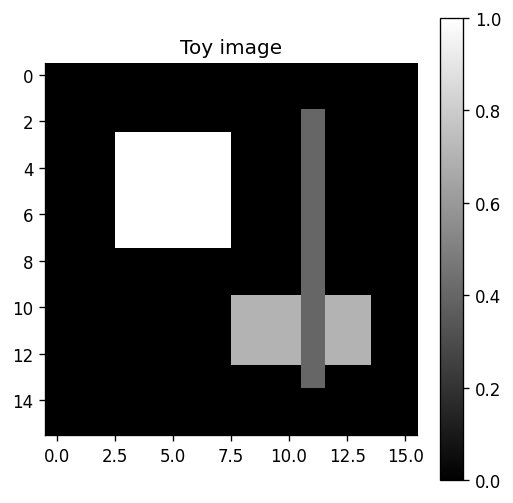

In [4]:
# ------------------------------
# 这段代码做什么：
# 1. 造一张很小的 toy 图像
# 2. 让 blur 的输入输出都能直观看见
# ------------------------------
def make_toy_image(h=16, w=16):
    img = np.zeros((h, w), dtype=np.float32)
    img[3:8, 3:8] = 1.0
    img[10:13, 8:14] = 0.7
    img[2:14, 11] = 0.4
    return img


toy_img = make_toy_image()

plt.figure(figsize=(5, 5))
plt.imshow(toy_img, cmap="gray", vmin=0, vmax=1)
plt.title("Toy image")
plt.colorbar()
plt.show()

### 这段 `blur2d_python` 代码到底在干什么

它做的是一个最朴素的 **`3x3` 均值模糊（average blur）**。  
可以先记一句最通俗的话：

> **对图像里的每个像素，取它周围 `3x3` 的邻域做平均，然后把这个平均值当成新的像素值。**

逐行看它在做什么：

- `h, w = img.shape`：取图像的高和宽
- `out = np.zeros_like(img)`：先准备一张同样大小的输出图
- `kernel = np.ones((3, 3)) / 9`：定义一个 `3x3` 的平均核
- 两层 `for` 循环：依次处理图像内部每个位置 `(i, j)`
- `patch = img[i-1:i+2, j-1:j+2]`：取当前位置周围的 `3x3` 小块
- `np.sum(patch * kernel)`：把这个小块做平均，得到输出像素

这里的 `kernel` 本质上就是：

$$
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

所以如果某个 `3x3` 邻域里只有中间一个点亮，周围都暗，那么平均之后这个亮点就会被“摊开”，图像看起来就会更模糊。

还要特别注意一个小细节：

- 循环从 `1` 到 `h-2`、`w-2`
- 这说明最外圈边界像素这里先不处理

也就是说，这段代码的重点不是“完美处理所有边界”，而是：

> **先把 stencil / convolution 最核心的邻域计算逻辑讲清楚。**

python blur time: 0.000328s


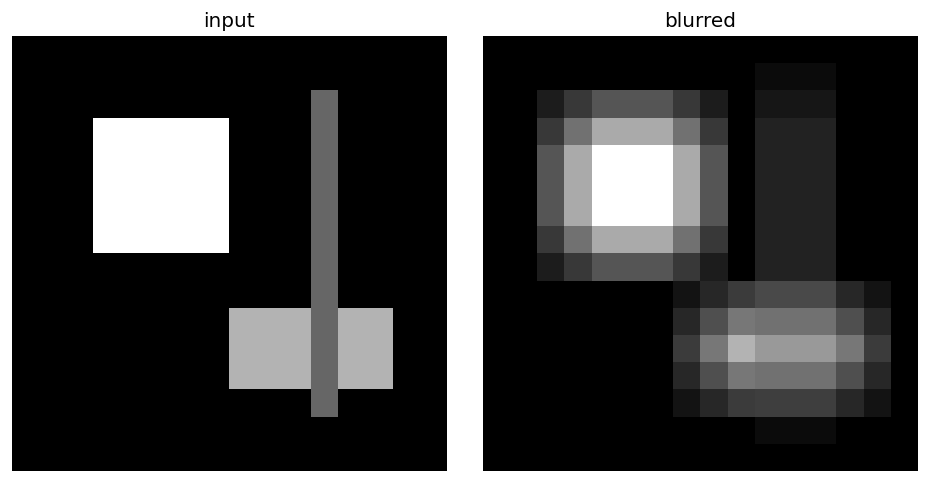

In [5]:
# ------------------------------
# 这段代码做什么：
# 1. 用最朴素的双重循环实现 3x3 blur
# 2. 让一个输出像素对应一个局部邻域
# ------------------------------
def blur2d_python(img):
    h, w = img.shape
    out = np.zeros_like(img)
    kernel = np.ones((3, 3), dtype=np.float32) / 9.0
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            patch = img[i - 1:i + 2, j - 1:j + 2]
            out[i, j] = np.sum(patch * kernel)
    return out


blurred_python, t_blur = benchmark(blur2d_python, toy_img, repeats=3)
print(f"python blur time: {t_blur:.6f}s")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(toy_img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("input")
axes[1].imshow(blurred_python, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("blurred")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 这里为什么已经很像 kernel 了

这段代码虽然还是 CPU loop，但思路已经和 kernel 很接近：

- 外层 `(i, j)` 就像“当前线程负责哪个输出像素”
- `patch = img[i-1:i+2, j-1:j+2]` 就像“这个线程去读自己附近的输入”

所以可以把它口语化成：

> **每个线程都在说：你把属于我的那 3x3 邻域拿来，我来算一个输出像素。**

In [6]:
# ------------------------------
# 这段代码做什么：
# 1. 随机挑一个输出像素
# 2. 把这个像素对应的 3x3 邻域手动打印出来
# 3. 让“一个线程干一件事”更具体
# ------------------------------
i, j = 6, 6
patch = toy_img[i - 1:i + 2, j - 1:j + 2]
print("chosen output position:", (i, j))
print("3x3 patch =")
print(np.round(patch, 2))
print("output value =", np.round(patch.mean(), 4))

chosen output position: (6, 6)
3x3 patch =
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
output value = 1.0


### 这段 `torch conv2d` 对照代码放在这里的目的是什么

这段代码不是在引入一个全新的问题，而是在说明一件很关键的事：

> **前面手写的 `blur2d_python`，本质上就是深度学习框架里的 `conv2d`。**

它放在这里主要有三个作用：

1. **把手写邻域计算和真实框架算子对上号**  
   前面手写的是：
   - 取一个 `3x3` 邻域
   - 乘上平均核
   - 再求和

   这里用 `F.conv2d` 做的其实还是同一件事。  
   也就是说，它在告诉大家：卷积并不是神秘黑盒，和前面的 stencil 逻辑是同一回事。

2. **验证前面的 Python 版本是对的**  
   这句：

   ```python
   print("max abs diff vs Python version =", np.max(np.abs(blurred_torch - blurred_python)))
   ```

   是在检查手写版结果和 `torch conv2d` 结果是不是一致。  
   如果误差很小，就说明前面的 `blur2d_python` 确实实现了一个正确的 blur / convolution。

3. **给后面讲 kernel 铺路**  
   这段代码最重要的教学价值其实是建立一条清楚的认知链：

   > **数学公式 -> 手写 stencil -> 框架算子 -> 底层 kernel 实现**

   也就是说，同一个操作可以有不同实现层次：

   - 最朴素版：Python 双循环
   - 框架版：`torch.nn.functional.conv2d`
   - 更底层：GPU kernel

如果只记一句话，可以记成：

> **这段代码是在证明：前面手写的 blur，不只是 toy demo，它和框架里的真实卷积算子本质上是同一个操作。**

max abs diff vs Python version = 5.9604645e-08


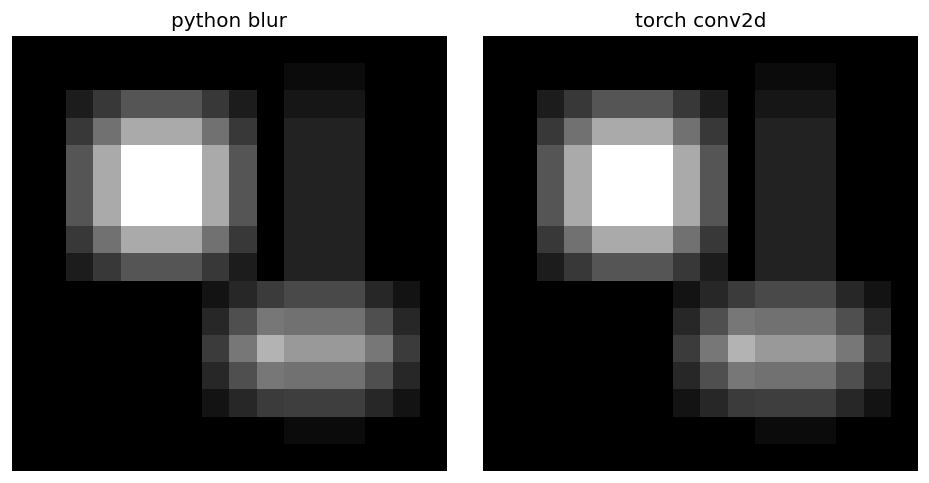

In [7]:
# ------------------------------
# 这段代码做什么：
# 1. 用 PyTorch 的 conv2d 实现同一个 blur
# 2. 让“手写 stencil”和“框架算子”对应起来
# ------------------------------
img_t = torch.tensor(toy_img)[None, None]
kernel_t = torch.ones((1, 1, 3, 3), dtype=torch.float32) / 9.0
blurred_torch = F.conv2d(img_t, kernel_t, padding=1)[0, 0].numpy()

print("max abs diff vs Python version =", np.max(np.abs(blurred_torch - blurred_python)))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(blurred_python, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("python blur")
axes[1].imshow(blurred_torch, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("torch conv2d")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 这一步要收束成什么结论

这里最重要的连接是：

- 视觉里的卷积，不只是“数学符号”
- 到了 kernel 层，它就是一个非常典型的 stencil 模式

所以如果后面真的去看 CUDA / Triton kernel，会发现：

- pointwise kernel 关心的是下标映射
- stencil kernel 除了下标映射，还关心邻域读取和边界

# Part 3. 为什么 block 和 tile 很重要

只会写 pointwise / stencil 还不够。  
真正进入高性能 kernel 设计时，最容易卡住的是：

> **不是算不对，而是访存太浪费。**

这就是 block、shared memory、tiling 这些概念出现的原因。

### 先把两个词讲清楚

先抓一句最重要的话：

> **`block` 解决“人怎么分组干活”，`tile` 解决“活怎么切块来做”。**

可以先这样理解：

- **block**：一组线程，也就是一个小工作组  
  这组线程可以更方便地协作、同步、共享一小块更快的存储。

- **tile**：从大数据里切出来的一小块数据或一小块输出区域  
  例如一张图里的一块区域，或者矩阵里一个 `16x16` 的小块。

所以后面经常会看到一个很常见的关系：

> **一个 block 负责一个 tile。**

### 一个通俗例子：批改试卷

可以把这件事想成批改试卷：

- 一整门课的所有试卷：像一整个大矩阵或一整张大图
- 一桌助教：像一个 `block`
- 分到这一桌的一小叠试卷：像一个 `tile`

如果没有 `tile` 的概念，会发生什么？

- 每个助教改一道题，都跑去总仓库拿材料
- 来回跑很多次
- 真正费时间的不是“改”，而是“取材料”

如果有 `tile` 的概念，就会变成：

- 先把这一小叠试卷搬到这桌
- 这一桌的人围着这小叠材料一起工作
- 同一份材料可以被这一组人反复使用

所以：

- `block` 是“哪几个人一起干”
- `tile` 是“这一组人手头这块活”

这就是为什么它们重要：  
**不是单纯多开一点线程，而是要让线程成组合作，并且围绕同一小块数据反复利用。**

### 再看一个更贴近计算的例子：矩阵乘法

假设要算：

$$
C = A @ B
$$

不会一口气让所有线程去乱算整个 `C`，更自然的方式是：

- 先把输出矩阵 `C` 切成很多小块，这些小块就是 `tile`
- 再让一个 `block` 的线程专门负责其中一个 `C tile`

为了算这个 `C tile`，这一组线程还会反复读取：

- `A` 的一个小块
- `B` 的一个小块

如果这些小块能先搬进更快的局部存储，再被这一组线程反复使用，就能显著减少慢内存访问。

所以矩阵乘法里：

- `block` 很重要，因为线程需要成组配合
- `tile` 很重要，因为数据需要先切块，才能高效复用

## memory hierarchy 的第一层直觉

这张图最核心的意思，其实可以先用一句话概括：

> **GPU 上很多时候不是“算得慢”，而是“取数据太慢”。**

所以它在讲的，是 `memory hierarchy`，也就是数据离计算单元有多近、访问有多快。

可以先把图里的三层这样理解：

- **global memory**：大、能放很多数据，但比较慢  
  可以把它想成“大仓库”。

- **shared memory**：一个 `block` 内线程共享的一小块更快存储  
  可以把它想成“这一桌人共用的小桌面”。

- **registers**：每个线程自己私有、最快的一小点存储  
  可以把它想成“每个人手里正拿着的几张纸”。

图上的箭头想表达的是：

- 先从 `global memory` 把一小块常用数据搬下来
- 这就是图里写的 `load tile`
- 然后 block 内的线程围绕这块数据反复使用
- 每个线程再把自己当前要算的那几个值放到寄存器里

所以这张图真正要讲的不是“背三层名字”，而是：

> **高性能 kernel 的关键，常常不是少做几次乘法，而是少去 global memory 反复拿同一份数据。**

这也就是为什么前面一直在讲 `block` 和 `tile`：

- **block** 重要，因为同一个 block 里的线程才能方便共享 `shared memory`
- **tile** 重要，因为要先把大数据切成一小块，才值得搬到更近的地方反复利用

最典型的例子还是矩阵乘法：

- 从大矩阵 `A`、`B` 里各取一小块 `tile`
- 先搬到更快的局部存储
- 再让一个 block 的线程反复利用它们做很多乘加

也就是说，这张图其实是在回答：

> **为什么“一个 block 负责一个 tile”常常是高性能实现里很自然的设计。**

<img src="images/lesson_kernel_intro/memory_hierarchy.png" width="920">

可以先记住最朴素的一句话：

> **能少去慢内存拿数据，就尽量少去。**

所以 block 的价值不只是“方便组织线程”，更重要的是：

- block 内线程能共享一小块数据
- 这让“先加载、再重复利用”成为可能

## 最经典的例子：矩阵乘法

<img src="images/lesson_kernel_intro/tiled_matmul.png" width="900">

矩阵乘法之所以常被拿来讲 kernel，不是因为它公式复杂，而是因为它非常适合说明：

- 为什么重复访存很贵
- 为什么 tile 能显著提高重用率

### 这段 `naive matmul` / `tiled matmul` 代码到底在讲什么

这块最核心的一句话是：

> **同样是矩阵乘法，数学公式没变，但如果把计算按小块 `tile` 来组织，数据访问会更高效。**

先看矩阵乘法本质上在算什么：

$$
C[i, j] = \sum_{kk=0}^{k-1} A[i, kk] \cdot B[kk, j]
$$

也就是说，`C` 的每个元素都要拿：

- `A` 的一行
- `B` 的一列
- 做一串乘加累积

`matmul_naive` 做的就是最朴素的版本：

- 外层 `i`：遍历 `C` 的行
- 中层 `j`：遍历 `C` 的列
- 内层 `kk`：沿着中间维度做累加

它的逻辑非常直接：  
**每次只算 `C[i, j]` 一个位置，算完再去算下一个位置。**

`matmul_tiled` 则不是一个个元素地算，而是：

> **先把输出矩阵 `C` 切成很多小块，再一块一块算。**

这三层块循环：

- `i0`：当前在算 `C` 的哪一块“行块”
- `j0`：当前在算 `C` 的哪一块“列块”
- `k0`：当前沿着中间维度取哪一小段来做部分累加

最关键的一句是：

```python
C[i0:i1, j0:j1] += A[i0:i1, k0:k1] @ B[k0:k1, j0:j1]
```

它的意思不是“换了一个新公式”，而是：

- 先从 `A` 里拿一个小块
- 再从 `B` 里拿一个小块
- 用这两个小块给 `C` 的一个小块增加一部分贡献

所以这里真正想讲的不是“矩阵乘法怎么定义”，而是：

> **`tile` 改变的是“怎么算、怎么拿数据”，不是“算什么”。**

也就是说：

- `naive` 和 `tiled` 算的是同一个矩阵乘法
- 但 `tiled` 更强调局部性和重复利用

这和前面讲的 `block / tile / memory hierarchy` 是直接连起来的：

- `tile`：先把大矩阵切成小块
- `block`：一组线程去负责一个输出块
- 先把相关小块搬近一点，再反复利用
- 这样比反复从大内存零散取数据更高效

`N = 96` 的作用只是选一个能跑完、又足够看出差异的矩阵尺寸。  
它不是理论必须，只是方便演示。

所以这整块代码的教学作用有三个：

1. 给一个最朴素的矩阵乘法基准版
2. 用 `tile` 版说明“高性能实现的关键是数据访问方式”
3. 给后面讲 GPU kernel、shared memory、一个 block 负责一个 tile 铺路

In [8]:
# ------------------------------
# 这段代码做什么：
# 1. 用三重循环实现 naive matmul
# 2. 用“按 tile 分块”的方式实现 tiled matmul
# 3. 让大家看到：tile 不是换公式，而是换数据访问方式
# ------------------------------
def matmul_naive(A, B):
    m, k = A.shape
    k2, n = B.shape
    assert k == k2
    C = np.zeros((m, n), dtype=np.float32)
    for i in range(m):
        for j in range(n):
            acc = 0.0
            for kk in range(k):
                acc += A[i, kk] * B[kk, j]
            C[i, j] = acc
    return C


def matmul_tiled(A, B, tile=16):
    m, k = A.shape
    k2, n = B.shape
    assert k == k2
    C = np.zeros((m, n), dtype=np.float32)
    for i0 in range(0, m, tile):
        for j0 in range(0, n, tile):
            for k0 in range(0, k, tile):
                i1 = min(i0 + tile, m)
                j1 = min(j0 + tile, n)
                k1 = min(k0 + tile, k)
                C[i0:i1, j0:j1] += A[i0:i1, k0:k1] @ B[k0:k1, j0:j1]
    return C


N = 96
A = np.random.randn(N, N).astype(np.float32)
B = np.random.randn(N, N).astype(np.float32)

with warnings.catch_warnings():
    # 当前环境的 NumPy / BLAS 在 matmul 时会吐出无害的 RuntimeWarning，
    # 结果本身是正常的，这里只是不让输出被这些 warning 干扰。
    warnings.simplefilter("ignore", RuntimeWarning)
    C_naive, t_naive = benchmark(matmul_naive, A, B, repeats=1)
    C_tiled, t_tiled = benchmark(matmul_tiled, A, B, repeats=3, tile=16)
    C_numpy, t_numpy = benchmark(lambda X, Y: X @ Y, A, B, repeats=5)

print("max abs diff (naive vs tiled) =", np.max(np.abs(C_naive - C_tiled)))
print("max abs diff (naive vs numpy) =", np.max(np.abs(C_naive - C_numpy)))
print(f"naive matmul time: {t_naive:.4f}s")
print(f"tiled matmul time: {t_tiled:.4f}s")
print(f"numpy @ time:      {t_numpy:.6f}s")

max abs diff (naive vs tiled) = 1.5258789e-05
max abs diff (naive vs numpy) = 7.6293945e-06
naive matmul time: 0.1084s
tiled matmul time: 0.0009s
numpy @ time:      0.000004s


In [9]:
# ------------------------------
# 这段代码做什么：
# 1. 不只看时间，还从“需要从大矩阵里读多少次数据”这个角度理解 tiling
# 2. 给出一个简单的理论读数估计
# ------------------------------
def approx_loads_naive(n):
    return 2 * (n ** 3)


def approx_loads_tiled(n, tile):
    return 2 * (n ** 3) / tile


for tile in [8, 16, 32]:
    print(f"tile={tile:>2d}, approx global loads ratio = {approx_loads_naive(N) / approx_loads_tiled(N, tile):.1f}x less")

tile= 8, approx global loads ratio = 8.0x less
tile=16, approx global loads ratio = 16.0x less
tile=32, approx global loads ratio = 32.0x less


### 这两格代码最关键的教学点

不要把 `tiling` 讲成“某种神秘优化技巧”。  
它最通俗的解释就是：

> **先把一小块数据搬到更近的地方，然后让很多计算重复利用这块数据。**

所以 tiled matmul 的核心不是“算得不一样”，而是：

- 数学公式没变
- 线程组织方式没变太多
- **数据访问方式变了**

# Part 4. 另一类特别常见的 kernel：reduction

前面两类都属于“一个输出位置对应一个线程”的思路。  
reduction 更麻烦，因为它的目标是：

> **把很多值合成一个值。**

例如：

- 求和
- 求最大值
- softmax 里的分母
- layer norm 里的均值和方差

## reduction 的树形直觉

<img src="images/lesson_kernel_intro/reduction_tree.png" width="900">

reduction 不适合简单地“一个线程只做一个最终输出”，因为最终输出就一个。  
所以更自然的思路是：

- 先让很多线程各自算一部分
- 再一层层往上合并

### `pairwise reduction` 的过程是在干什么

它做的事情可以先用一句话概括：

> **把很多数，一层一层地两两合并，最后变成一个数。**

最常见的例子就是求和。  
假设输入是：

```python
[3, 1, 4, 1, 5, 9, 2, 6]
```

那 `pairwise reduction` 会这样走：

1. 第一轮两两相加  
   `[3+1, 4+1, 5+9, 2+6] = [4, 5, 14, 8]`

2. 第二轮再两两相加  
   `[4+5, 14+8] = [9, 22]`

3. 第三轮再合并  
   `[9+22] = [31]`

最后就得到总和 `31`。

它为什么叫 `pairwise`？  
因为每一轮都是：

- 先分成一对一对
- 每对先合并
- 再进入下一轮

它放在这节课里的作用，不是为了教“怎么求和”本身，而是为了说明：

> **reduction 这种 `many -> one` 的计算，怎么组织成并行会更自然。**

因为顺序求和像这样：

```python
((((3+1)+4)+1)+5)+...
```

更像一个人从头加到尾。  
但 `pairwise reduction` 是树形的：

- 第一轮很多对可以同时算
- 第二轮也可以同时算
- 每一层都能并行一部分

所以这段代码真正想说明的是：

> **reduction 不是“一个线程对应一个输出”的模式，而是“很多局部结果要不断合并”的模式。**

In [10]:
# ------------------------------
# 这段代码做什么：
# 1. 手写一个 pairwise reduction 的过程
# 2. 让“树形合并”从抽象概念变成看得见的阶段结果
# ------------------------------
def reduction_stages(x):
    stages = [x.copy()]
    cur = x.copy()
    while len(cur) > 1:
        if len(cur) % 2 == 1:
            cur = np.append(cur, 0.0)
        cur = cur.reshape(-1, 2).sum(axis=1)
        stages.append(cur.copy())
    return stages


x_small = np.array([3, 1, 4, 1, 5, 9, 2, 6], dtype=np.float32)
stages = reduction_stages(x_small)
for level, arr in enumerate(stages):
    print(f"level {level}: {arr}")

level 0: [3. 1. 4. 1. 5. 9. 2. 6.]
level 1: [ 4.  5. 14.  8.]
level 2: [ 9. 22.]
level 3: [31.]


In [11]:
# ------------------------------
# 这段代码做什么：
# 1. 对比 Python 顺序求和和 NumPy 求和
# 2. 说明 reduction 在实现上往往很依赖高效并行
# ------------------------------
def sum_python(x):
    s = 0.0
    for v in x:
        s += float(v)
    return s


big = np.random.randn(1_000_000).astype(np.float32)
s_python, t_sum_python = benchmark(sum_python, big, repeats=1)
s_numpy, t_sum_numpy = benchmark(np.sum, big, repeats=5)

print("difference =", abs(s_python - float(s_numpy)))
print(f"python sum time: {t_sum_python:.4f}s")
print(f"numpy  sum time: {t_sum_numpy:.6f}s")

difference = 0.0009054299907802488
python sum time: 0.0264s
numpy  sum time: 0.000105s


### 为什么 reduction 往往比 pointwise 更难写

因为 pointwise 很自然：

- 一个输出元素
- 一个线程

reduction 则会遇到更多并行问题：

- 局部结果先放哪
- 不同线程怎么同步
- 如何避免大量线程都在等少数线程

所以很多高性能 kernel 难点不在“乘法加法”，而在：

> **线程之间怎么协作。**

# Part 5. 真实 kernel 代码应该怎么看

如果第一次看 CUDA / Triton，很容易被语法吓住。  
但更稳的看法是：先不看细节，先找下面这四件事。

1. 输入和输出是什么
2. 一个线程负责哪个输出位置
3. 边界条件在哪
4. 有没有显式做 tile / 缓存 / reduction

## 一个更完整一点的 blur kernel 骨架

```cpp
__global__ void blur3x3_kernel(const float* x, float* y, int H, int W) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row >= H || col >= W) return;

    float acc = 0.0f;
    int cnt = 0;
    for (int di = -1; di <= 1; ++di) {
        for (int dj = -1; dj <= 1; ++dj) {
            int r = row + di;
            int c = col + dj;
            if (0 <= r && r < H && 0 <= c && c < W) {
                acc += x[r * W + c];
                cnt += 1;
            }
        }
    }
    y[row * W + col] = acc / cnt;
}
```

读这段 kernel，不要急着背 API。  
先问：

- 线程负责哪个像素？答：`(row, col)`
- 如何避免越界？答：两层边界判断
- 计算模式是什么？答：stencil / neighborhood gather

## 如果以后切到 Triton，应该抓什么

Triton 常让第一次接触 kernel 的人更容易上手，因为它把很多显式 CUDA 细节藏起来了一部分。  
但无论是 CUDA 还是 Triton，真正不变的仍然是同一套问题：

- 一个程序实例处理哪块数据
- 数据怎么切块
- 哪些值值得缓存复用
- 边界和掩码怎么处理

所以：

> **先把 kernel 思维建立起来，再换工具；不要反过来。**

# Part 6. 回到 PyTorch：什么时候真的需要自己写 kernel

很多时候并不需要自己写。  
先用好框架自带算子，往往已经足够。

更可能需要自己写 kernel 的场景通常是：

1. 有很特别的自定义算子
2. 几个小算子来回读写内存，想做融合
3. 某个算子已经是性能瓶颈，而且现成实现不合适

也可以这样理解：

- `DDP` 决定多卡怎么一起训练
- `autograd` 决定梯度怎么传
- `kernel` 决定单个算子在设备上怎么跑

三者在系统里都重要，但层次不同。

### 练习题里这个 `pointwise` 到底是什么意思

这里的 `pointwise` 指的是：

> **逐元素计算。**

也就是：

- 输入里有多少个位置
- 输出里就有多少个位置
- 每个输出位置只依赖对应位置的输入值，不需要看邻居，也不需要和别的位置做汇总

例如：

```python
y[i] = a * x[i] + y[i]
```

就是一个典型的 `pointwise` 操作。  
把它改成：

```python
y[i] = relu(a * x[i] + y[i])
```

以后，它仍然是 `pointwise`，因为第 `i` 个输出依然只看第 `i` 个位置的输入。

所以这道练习题真正想让人意识到的是：

> **只要每个输出位置都能独立计算，这类操作通常就属于 pointwise。**

In [12]:
# ------------------------------
# 这段代码做什么：
# 1. 给出一个小实战练习模板
# 2. 把 pointwise / stencil / reduction 三类 kernel 模式放到同一页
# ------------------------------
practice = {
    "pointwise": "把 y = a*x + y 改成 y = relu(a*x + y)",
    "stencil": "把 3x3 平均 blur 改成 Sobel 边缘算子",
    "reduction": "把 sum 改成 max，并思考 softmax 里为什么先要做 max reduction",
}

for k, v in practice.items():
    print(f"[{k}] {v}")

[pointwise] 把 y = a*x + y 改成 y = relu(a*x + y)
[stencil] 把 3x3 平均 blur 改成 Sobel 边缘算子
[reduction] 把 sum 改成 max，并思考 softmax 里为什么先要做 max reduction


## 这一讲最后要收束成哪三句话

1. **kernel 不是神秘底层魔法，它就是把一个操作拆给很多线程并行执行。**
2. **写 kernel 的核心不是背 API，而是想清楚：线程负责什么、数据怎么访问、哪些值值得复用。**
3. **视觉里的卷积、系统里的 matmul、训练里的 reduction，本质上都是不同形态的 kernel。**